# Phase 2  Engineer & Transform Features

----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
from google.colab import files
files.upload()

Saving final-project.ipynb to final-project.ipynb


{'final-project.ipynb': b'{"metadata":{"kernelspec":{"language":"python","display_name":"Python 3","name":"python3"},"language_info":{"name":"python","version":"3.12.12","mimetype":"text/x-python","codemirror_mode":{"name":"ipython","version":3},"pygments_lexer":"ipython3","nbconvert_exporter":"python","file_extension":".py"},"kaggle":{"accelerator":"none","dataSources":[{"sourceType":"datasetVersion","sourceId":15022147,"datasetId":9616012,"databundleVersionId":15899681}],"dockerImageVersionId":31286,"isInternetEnabled":false,"language":"python","sourceType":"notebook","isGpuEnabled":false}},"nbformat_minor":4,"nbformat":4,"cells":[{"cell_type":"markdown","source":"> >Phace-1            ","metadata":{}},{"cell_type":"markdown","source":"First I import the libraries that I will use for data cleaning","metadata":{}},{"cell_type":"markdown","source":"I load the data using pd.read_csv() and then print the first 5 rows to see what the data looks like","metadata":{}},{"cell_type":"code","so

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
def Load_data():
    path = kagglehub.dataset_download("prevek18/ames-housing-dataset")
    file_path= os.path.join(path,"AmesHousing.csv")
    df= pd.read_csv(file_path)
    print("First 5 raw: ", df.head())
    return df
df= Load_data()

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
First 5 raw:     Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv   

using get_dummies we converted the columns to categorical
which means the values inside street become one column with 0 and 1
then we printed the first 5 rows to see the final shape after transformation

In [5]:
df= pd.get_dummies(df, columns=['MS Zoning', 'Street'], drop_first=True)
print(df.head())

   Order        PID  MS SubClass  Lot Frontage  Lot Area Alley Lot Shape  \
0      1  526301100           20         141.0     31770   NaN       IR1   
1      2  526350040           20          80.0     11622   NaN       Reg   
2      3  526351010           20          81.0     14267   NaN       IR1   
3      4  526353030           20          93.0     11160   NaN       Reg   
4      5  527105010           60          74.0     13830   NaN       IR1   

  Land Contour Utilities Lot Config  ... Sale Type Sale Condition SalePrice  \
0          Lvl    AllPub     Corner  ...       WD          Normal    215000   
1          Lvl    AllPub     Inside  ...       WD          Normal    105000   
2          Lvl    AllPub     Corner  ...       WD          Normal    172000   
3          Lvl    AllPub     Corner  ...       WD          Normal    244000   
4          Lvl    AllPub     Inside  ...       WD          Normal    189900   

  MS Zoning_C (all) MS Zoning_FV MS Zoning_I (all)  MS Zoning_RH  \


some columns are ordinal like quality so ordinal encoder converted them to numbers
and fit_transform we applied the encoding on Exter Qual column

In [6]:
QualOrder= ['Fa', 'TA', 'Gd', 'Ex']
Encoder= OrdinalEncoder(categories= [QualOrder])
df['Exter Qual']= Encoder.fit_transform(df[['Exter Qual']])

x is all columns except SalePrice
y is the target column SalePrice
i split the data into 80 training and 20 testing
random_state 7 so every time i run the code i get the same result same split and it does not change
StandardScaler converts values to Z score value minus mean divided by standard deviation we use it when the column has big numbers
fit_transform for training data only
transform for testing data only

In [7]:
x= df.drop("SalePrice", axis=1)
y= df["SalePrice"]
X_train, X_test, y_train, y_test= train_test_split(x ,y, test_size=0.2, random_state=7)
scaler= StandardScaler()
X_train[["Gr Liv Area", "Lot Area"]]= scaler.fit_transform(X_train[["Gr Liv Area", "Lot Area"]])
X_test[["Gr Liv Area", "Lot Area"]]= scaler.transform(X_test[["Gr Liv Area", "Lot Area"]])


pricePerSqft means price per square foot
and we replaced any zero value in Gr Liv Area column with NaN to avoid division by zero

In [8]:
df["pricePerSqft"]= df["SalePrice"]/df["Gr Liv Area"].replace(0, np.nan)

we combined full bathrooms and half bathrooms into one variable and the half bathroom becomes 0.5
 this feature combines quality and area so the model understands big and good houses together

In [9]:
df["TotalBathrooms"]= df["Full Bath"]+(0.5*df["Half Bath"])

this feature combines quality and area so the model understands big and good houses together


In [10]:
df["QualityXArea"]= df["Overall Qual"]*df["Gr Liv Area"]

sometimes there are big values so the distribution is skewed so we used log1p to reduce big values and make it closer to normal distribution and i made histogram before and after to see the difference

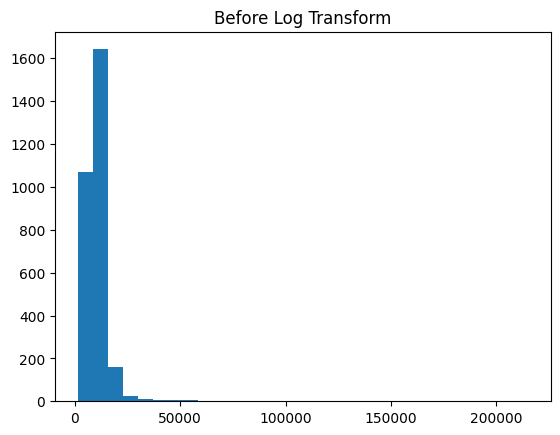

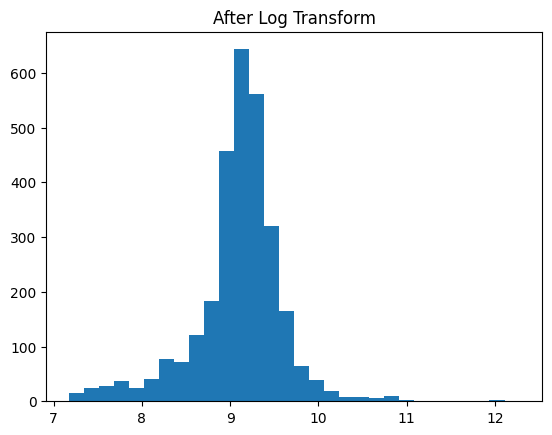

In [11]:
plt.hist(df["Lot Area"], bins= 30)
plt.title("Before Log Transform")
plt.show()

df["Lot Area"]= np.log1p(df['Lot Area'])
plt.hist(df['Lot Area'], bins= 30)
plt.title("After Log Transform")
plt.show()

here to know if the house is new recent or old using the year built
pd cut converts each house age into a category
less than 10 years new
between 10 and 40 recent
more than 40 old


In [12]:
bins= [0, 10, 40,200]
labels= ["New", "Recent", "Old"]
df["HouseAgeGroup"]= pd.cut(2024-df["Year Built"], bins= bins, labels= labels)

df_numeric for numeric columns only
CorrMatrix shows the correlation between each column and column
upper we kept only the upper half to avoid repeating values
Drop for columns that are highly correlated we dropped them to reduce multicollinearity and improve the model

In [13]:
df_numeric= df.select_dtypes(include=[np.number])
CorrMatrix= df_numeric.corr().abs()
Upper= CorrMatrix.where(np.triu(np.ones(CorrMatrix.shape), k=1).astype(bool))
Drop= [column for column in Upper.columns if any(Upper[column]>0.95)]
df= df.drop(columns=Drop)